<a href="https://colab.research.google.com/github/himasree33/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights-/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('train.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

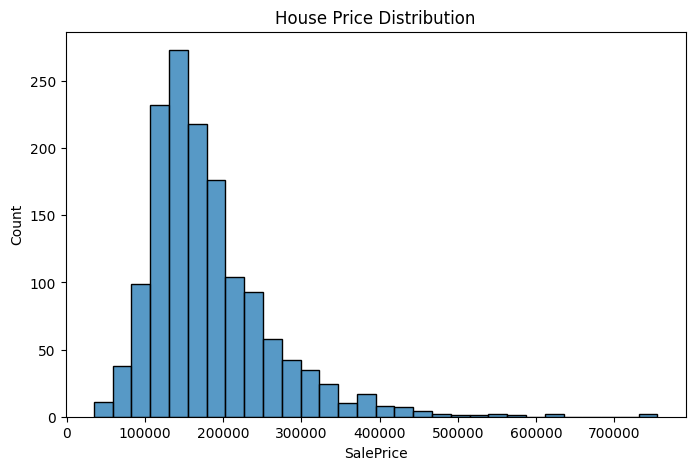

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['SalePrice'], bins=30)

plt.title("House Price Distribution")
plt.show()


In [7]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [8]:
corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False).head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


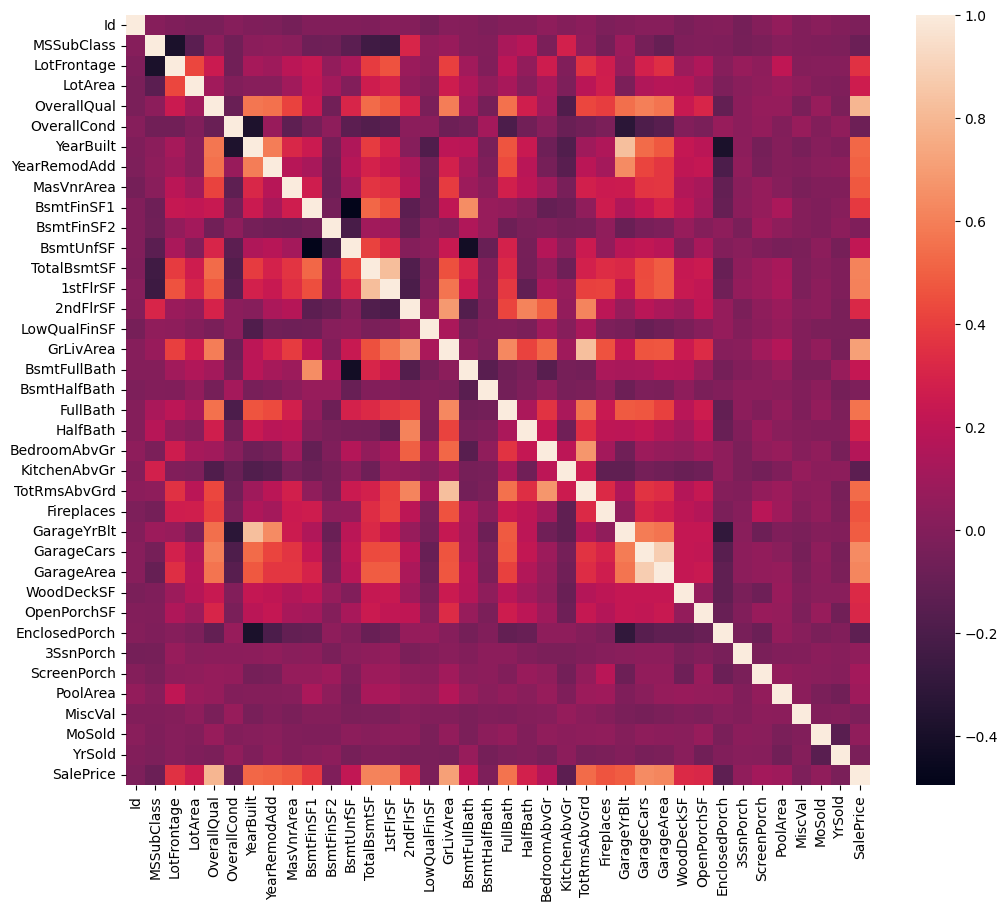

In [9]:
plt.figure(figsize=(12,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr)

plt.show()

In [12]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF"
]

X = df[features]
y = df["SalePrice"]

In [13]:
X = X.fillna(X.mean())

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [16]:
predictions = model.predict(X_test)

predictions[:5]

array([143522.47855694, 288596.45355634, 136156.55446308, 187027.68704309,
       293501.0547308 ])

In [17]:
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 25446.0547392125
R2 Score: 0.7910239048318479


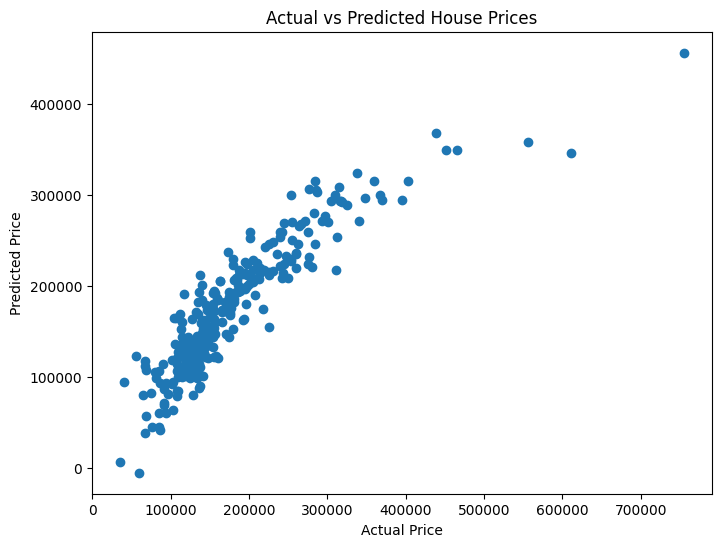

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [19]:
!pip install gradio

In [22]:
!pip install -q gradio

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Prediction Function
# ---------------------------

def predict_price(quality, area, garage, basement):

    pred = model.predict([[quality, area, garage, basement]])[0]

    if pred < 150000:
        category = "🏠 Budget Home"
    elif pred < 300000:
        category = "🏡 Mid-Range Home"
    else:
        category = "🏰 Luxury Home"

    card = f"""
    <div style="
        background:#1e1e1e;
        padding:25px;
        border-radius:20px;
        text-align:center;
        color:white;
        box-shadow:0 4px 20px rgba(0,0,0,0.4);
    ">
        <h2>💰 Estimated House Price</h2>
        <h1>${pred:,.0f}</h1>
        <h3>{category}</h3>
    </div>
    """

    fig, ax = plt.subplots(figsize=(6,3))

    ax.bar(
        ["Predicted Price"],
        [pred]
    )

    ax.set_ylabel("Price ($)")
    ax.set_title("Predicted House Value")

    plt.tight_layout()

    return card, fig


# ---------------------------
# UI
# ---------------------------

with gr.Blocks(
    theme=gr.themes.Monochrome(),
    title="House Price Predictor"
) as demo:

    gr.Markdown("""
    # 🏠 House Price Predictor

    ### Predict housing prices using Machine Learning

    Enter the house details below and receive an instant estimate.
    """)

    with gr.Row():

        with gr.Column():

            quality = gr.Slider(
                minimum=1,
                maximum=10,
                value=5,
                step=1,
                label="⭐ Overall Quality"
            )

            area = gr.Number(
                value=1500,
                label="📏 Living Area (sq ft)"
            )

            garage = gr.Number(
                value=2,
                label="🚗 Garage Capacity"
            )

            basement = gr.Number(
                value=1000,
                label="🏢 Basement Area (sq ft)"
            )

            predict_btn = gr.Button(
                "Predict Price 💰",
                variant="secondary"
            )

        with gr.Column():

            output_card = gr.HTML()

            output_graph = gr.Plot(
                label="📈 Prediction Visualization"
            )

    predict_btn.click(
        fn=predict_price,
        inputs=[
            quality,
            area,
            garage,
            basement
        ],
        outputs=[
            output_card,
            output_graph
        ]
    )

    gr.Markdown("""
    ---
    ### 📊 Model Details

    **Algorithm:** Linear Regression

    **Features Used**
    - Overall Quality
    - Living Area
    - Garage Capacity
    - Basement Area

    **Model Performance**
    - R² Score: 0.79
    - MAE: 25,446

    Built using Scikit-Learn + Gradio
    """)

demo.launch(share=True)

/tmp/ipykernel_842/3308934013.py:56: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://442627da07643ec994.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
